<a href="https://colab.research.google.com/github/hdflorez/Entrega_2/blob/main/dataset_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Datos (190304018-1 ) 2026-1** | **Entrega 2** |

**Integrantes del equipo:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Fase 1: Exploración de Base de datos** | **Dataset 2: UrbanSound8K** |

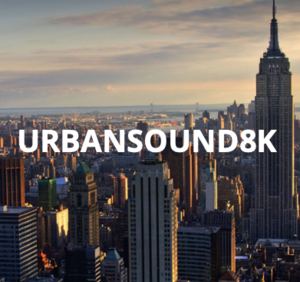

## **Generalidades del dataset**
El dataset UrbanSound8K, disponible en Kaggle y originado a partir de grabaciones de campo publicadas en Freesound, comprende 8732 fragmentos de audio etiquetados de hasta 4 segundos, clasificados en 10 categorías de sonidos urbanos: aire acondicionado, bocina de coche, niños jugando, ladrido de perro, taladro, motor al ralentí, disparo de arma, martillo neumático, sirena y música callejera. Al tratarse de datos recolectados y curados por terceros, se clasifica como una fuente secundaria, y combina datos no estructurados (audio) con un archivo estructurado de metadatos en formato CSV.

Su nivel de documentación es alto: cuenta con un artículo académico de respaldo, metadatos bien definidos y una organización en diez grupos (fold1 a fold10) pensada para facilitar experimentos de machine learning, lo que lo convierte en un recurso especialmente accesible para proyectos de clasificación. Entre sus principales aplicaciones se encuentran la clasificación de audio, el desarrollo de soluciones para ciudades inteligentes y la detección de eventos sonoros como sirenas o tráfico. En términos generales, presenta alta completitud, relevancia y documentación, aunque su manejabilidad es media debido a que requiere procesamiento de audio.

Puede consultarse en: https://www.kaggle.com/datasets/chrisfilo/urbansound8k

## Fuente y tipo de datos
 * Fuente: Kaggle
 * Origen real: grabaciones obtenidas de la plataforma Freesound.  ￼
 * Tipo de datos:
   * Secundaria, ya que los datos fueron recolectados y curados por terceros.
 * Tipo de dataset:
   * Datos no estructurados (audio) + archivo estructurado (metadata en CSV).

## Características
  * Registros: 8,732 audios
  * Clases: 10 categorías de sonidos urbanos
  * Duración: hasta 4 segundos
  * Tamaño: ~5.6 GB
  * Estructura: 10 folds para validación

## Nivel de Documentación disponible y posibles aplicaciones

  * Documentación:

      * Alto nivel de documentación:
      * Incluye paper académico.
      * Metadata clara y bien definida.
      * Organización lista para machine learning (folds).
      * Ventaja: fácil de usar en proyectos de clasificación.
  * Aplicaciones:
    * Clasificación de audio
    * Ciudades inteligentes
    * Detección de eventos (sirenas, tráfico, etc.)


  * Completitud: Alta
  * Relevancia: Alta
  * Documentación: Alta
  * Manejabilidad: Media (requiere procesamiento de audio)


In [ ]:
# Instalar Kaggle
!pip install kaggle

# Subir kaggle.json
from google.colab import files
files.upload()

# Configurar credenciales
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

Saving creditcard.csv to creditcard.csv


In [ ]:
# Descargar dataset desde Kaggle
!kaggle datasets download -d chrisfilo/urbansound8k

# Descomprimir
import zipfile

with zipfile.ZipFile("urbansound8k.zip", 'r') as zip_ref:
    zip_ref.extractall("UrbanSound8K")

print("Dataset descargado y descomprimido correctamente")

Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.61G/5.61G [01:40<00:00, 60.2MB/s]

Dataset descargado y descomprimido correctamente


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('default')
sns.set_palette("husl")

In [ ]:
metadata_path = "UrbanSound8K/UrbanSound8K.csv"

df = pd.read_csv(metadata_path)

print("Dataset cargado correctamente")

Dataset cargado correctamente


In [ ]:
print("=== INFORMACIÓN GENERAL ===")
df.info()

print("\n=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== ESTADÍSTICAS ===")
display(df.describe())

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB

=== PRIMERAS FILAS ===


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing



=== ESTADÍSTICAS ===


,fsID,start,end,salience,fold,classID
count,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000
mean,116033.493816,38.645409,42.253312,1.347000,5.385937,4.592877
std,57991.017218,74.292126,74.369669,0.476043,2.846820,2.894544
min,344.000000,0.000000,0.105962,1.000000,1.000000,0.000000
25%,69942.250000,3.000000,6.839398,1.000000,3.000000,2.000000
50%,118279.000000,10.376492,14.000000,1.000000,5.000000,4.000000
75%,166942.000000,35.131372,38.866979,2.000000,8.000000,7.000000
max,209992.000000,600.125356,604.125356,2.000000,10.000000,9.000000


In [ ]:
import librosa
import librosa.display
from IPython.display import Audio
import os

# Se puede cambiar el índice para seleccionar un audio diferente, por ejemplo, para el audio en la posición 50 (índice 49):
sample = df.iloc[80]

audio_path = os.path.join(
    "UrbanSound8K",
    f"fold{sample['fold']}",
    sample['slice_file_name']
)

# Cargar el audio usando librosa
y, sr = librosa.load(audio_path)

print(f"Reproduciendo: {sample['class']} de la ruta: {audio_path}")
Audio(y, rate=sr)

Reproduciendo: air_conditioner de la ruta: UrbanSound8K/fold9/101729-0-0-26.wav


In [ ]:
from IPython.display import Audio
import os

# Seleccionamos el primer audio del DataFrame como ejemplo
sample = df.iloc[0]
audio_path = os.path.join(
    "UrbanSound8K",
    f"fold{sample['fold']}",
    sample['slice_file_name']
)

print(f"Reproduciendo: {sample['class']} de la ruta: {audio_path}")
Audio(audio_path)

Reproduciendo: dog_bark de la ruta: UrbanSound8K/fold5/100032-3-0-0.wav


In [ ]:
print("=== VALORES FALTANTES ===")
missing = df.isnull().sum()
display(missing[missing > 0])

=== VALORES FALTANTES ===


,0


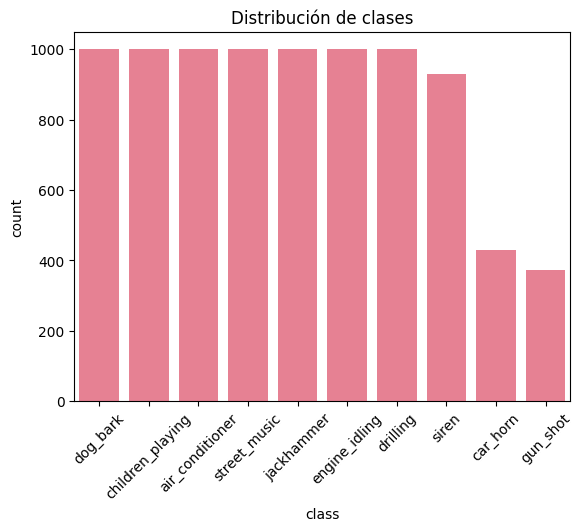

In [ ]:
plt.figure()
sns.countplot(data=df, x="class", order=df["class"].value_counts().index)
plt.title("Distribución de clases")
plt.xticks(rotation=45)
plt.show()

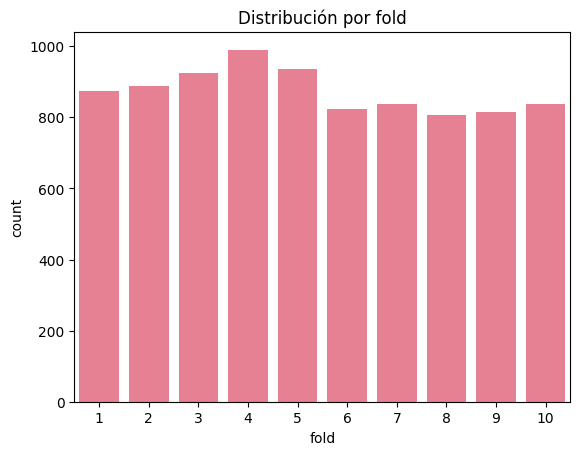

In [ ]:
plt.figure()
sns.countplot(data=df, x="fold")
plt.title("Distribución por fold")
plt.show()

In [ ]:
sample = df.iloc[0]

audio_path = os.path.join(
    "UrbanSound8K",
    "audio",
    f"fold{sample['fold']}",
    sample['slice_file_name']
)

print("Clase:", sample['class'])
print("Ruta:", audio_path)

Clase: dog_bark
Ruta: UrbanSound8K/audio/fold5/100032-3-0-0.wav


In [ ]:
sample = df.iloc[0]

audio_path = os.path.join(
    "UrbanSound8K",
    "audio",
    f"fold{sample['fold']}",
    sample['slice_file_name']
)

print("Clase:", sample['class'])
print("Ruta:", audio_path)

Clase: dog_bark
Ruta: UrbanSound8K/audio/fold5/100032-3-0-0.wav


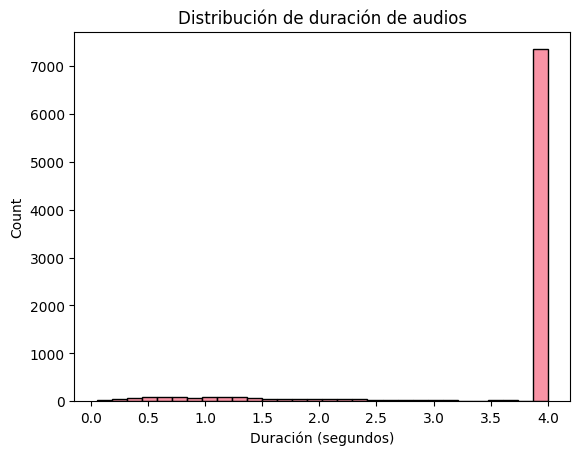

In [ ]:
plt.figure()
sns.histplot(df["end"] - df["start"], bins=30)
plt.title("Distribución de duración de audios")
plt.xlabel("Duración (segundos)")
plt.show()